In [77]:
from collections import defaultdict, Counter
from IPython.display import display
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from datetime import datetime
from graphviz import Digraph
import plotly.express as px
import pandas as pd
import json
import os


In [78]:
data_dir = "../data"
raw_dir = os.path.join(data_dir, "processed")
session_dir = os.path.join(raw_dir, "merged")
gameplay_dir = os.path.join(session_dir, "Gameplay")
traces_path = os.path.join(gameplay_dir, "traces.ndjson")


In [79]:
with open(traces_path, "r", encoding="utf-8") as f:
	print(repr(f.read()[:200]))
	

'{"actor": {"account": {"name": "684837aae48b5a00221a37c9_fwme", "homePage": "https://simva-beta.e-ucm.es"}}, "result": {"extensions": {"https://w3id.org/xapi/seriousgame/extensions/Sexuality": "hetero'


In [80]:
df = pd.read_json(traces_path, lines=True)
display(df.head())


,actor,result,stored,authority,verb,context,id,version,timestamp,object
0,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:45:15.365Z,"{'name': '684837aae48b5a00221a37c9_fwme', 'hom...","{'display': {'en-US': 'initialized'}, 'id': 'h...",{'contextActivities': {'category': [{'id': 'ht...,e8aa9f32-22db-4f33-bd7a-9f13dd73bf96,1.0.2,2025-06-11 10:42:58.869000+00:00,{'definition': {'name': {'en-US': 'serious-gam...
1,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:45:15.365Z,"{'name': '684837aae48b5a00221a37c9_fwme', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,a2af535f-67ed-4d74-91b1-2ed7071e195c,1.0.2,2025-06-11 10:42:59.082000+00:00,"{'definition': {'name': {'en-US': 'cutscene'},..."
2,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:45:15.365Z,"{'name': '684837aae48b5a00221a37c9_fwme', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,6f51b793-d7ee-4a30-9dc8-1838ba307ca6,1.0.2,2025-06-11 10:43:03.048000+00:00,"{'definition': {'name': {'en-US': 'area'}, 'de..."
3,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:44:31.798Z,"{'name': '684837aae48b5a00221a37c9_newj', 'hom...","{'display': {'en-US': 'initialized'}, 'id': 'h...",{'contextActivities': {'category': [{'id': 'ht...,78a674d5-2f92-4a02-be29-6f8fc06e3565,1.0.2,2025-06-11 10:43:03.271000+00:00,{'definition': {'name': {'en-US': 'serious-gam...
4,{'account': {'name': '684837aae48b5a00221a37c9...,{'extensions': {'https://w3id.org/xapi/serious...,2025-06-11T10:44:31.798Z,"{'name': '684837aae48b5a00221a37c9_newj', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,273af825-cc45-453b-ba1e-5b72f3eb7899,1.0.2,2025-06-11 10:43:03.486000+00:00,"{'definition': {'name': {'en-US': 'cutscene'},..."


In [81]:
traces = []
invalid_count = 0

with open(traces_path, "r", encoding="utf-8") as f:
	for line in f:
		line = line.strip()
		if line:
			try:
				traces.append(json.loads(line))
			except json.JSONDecodeError:
				invalid_count += 1

print("Total valid traces:", len(traces))
print("Total invalid traces:", invalid_count)


Total valid traces: 76008
Total invalid traces: 0


In [82]:
GAME_START_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/serious-game/GameStart"
GAME_END_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/serious-game/GameEnd"
GENDER_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Gender"
SEXUALITY_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Sexuality"


In [83]:
start_counts = Counter()
end_counts = Counter()

for trace in traces:
	user = trace["actor"]["account"]["name"]
	obj_id = trace.get("object", {}).get("id", "")

	if obj_id == GAME_START_OBJ_ID:
		start_counts[user] += 1
	elif obj_id == GAME_END_OBJ_ID:
		end_counts[user] += 1

print("Max starts per user:", max(start_counts.values()))
print("Max ends per user:", max(end_counts.values()))


Max starts per user: 1
Max ends per user: 1


In [84]:
users = set()

user_profile = defaultdict(lambda: {
	"gender": None,
	"sexuality": None,
})

for trace in traces:
	user = trace.get("actor", {}).get("account", {}).get("name")
	if user:
		users.add(user)

		result = trace.get("result", {})
		extensions = result.get("extensions", {}) or {}
		
		if user_profile[user]["gender"] is None:
			user_profile[user]["gender"] = extensions.get(GENDER_EXT_ID)
		
		if user_profile[user]["sexuality"] is None:
			user_profile[user]["sexuality"] = extensions.get(SEXUALITY_EXT_ID)

		obj_id = trace.get("object", {}).get("id", "")

print("Total users:", len(users))


Total users: 81


In [85]:
df = pd.DataFrame.from_dict(user_profile, orient="index").reset_index()
df.rename(columns={"index": "user"}, inplace=True)

print(df.head())


                            user  gender     sexuality
0  684837aae48b5a00221a37c9_fwme    male  heterosexual
1  684837aae48b5a00221a37c9_newj    male  heterosexual
2  684837aae48b5a00221a37c9_vboy    male  heterosexual
3  684837aae48b5a00221a37c9_ndkj  female  heterosexual
4  684837aae48b5a00221a37c9_cgph  female  heterosexual


sexuality  bisexual  heterosexual  homosexual
gender                                       
female            0            25          18
male              1            23          14


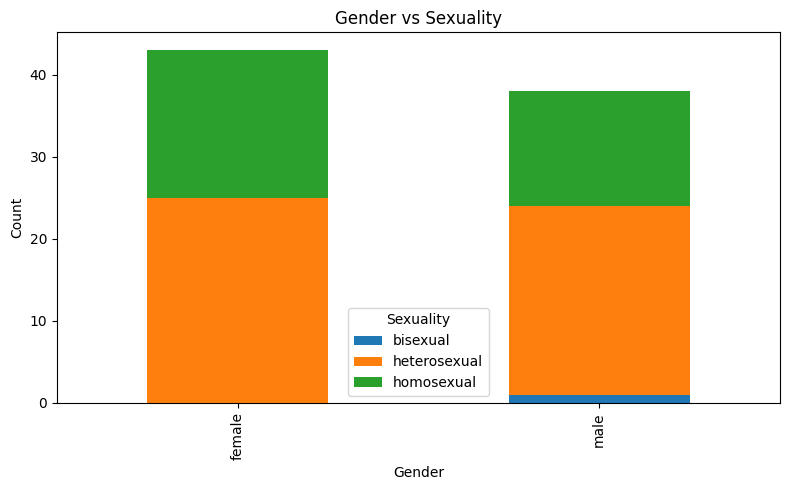

In [86]:
cross = pd.crosstab(df["gender"], df["sexuality"])

print(cross)

cross.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Gender vs Sexuality")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Sexuality")
plt.tight_layout()
plt.show()


In [87]:
NODE_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Node"
RESPONSE_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Response"
CHOICE_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/OptionSelect"


In [88]:
node_counts = defaultdict(int)
node_response_counts = defaultdict(Counter)

for trace in traces:
	obj_id = trace.get("object", {}).get("id", "")
	
	if obj_id == CHOICE_OBJ_ID:
		extensions = trace.get("result", {}).get("extensions", {}) or {}

		node = extensions.get(NODE_EXT_ID)
		response = extensions.get(RESPONSE_EXT_ID)

		if node:
			node_counts[node] += 1

		if node and response:
			node_response_counts[node][response] += 1
			
print("Number of choice nodes:", len(node_counts))


Number of choice nodes: 53


In [89]:
rows = []

for node in node_counts:
	rows.append({
		"node": node,
		"total_selections": node_counts[node],
		"unique_choices": len(node_response_counts[node])
	})

df_nodes = pd.DataFrame(rows)

display(df_nodes.head())


,node,total_selections,unique_choices
0,Scene1Classroom.part2.thanks,94,4
1,Scene1Lunch1.main.choices,92,2
2,Scene1Lunch1.phone.choices,90,1
3,Scene1Bedroom1.computer1.choices,90,2
4,Scene1Bedroom1.computer1.choices2,90,2


In [90]:
most_chosen = {}

for node, counter in node_response_counts.items():
	option, count = counter.most_common(1)[0]
	most_chosen[node] = {
		"option": option,
		"count": count
	}

for node, data in most_chosen.items():
	print(node, "->", data["option"])
	

Scene1Classroom.part2.thanks -> Igualmente, encantada de conocerte *sonríes*.
Scene1Lunch1.main.choices -> Contarles sobre mi día.
Scene1Lunch1.phone.choices -> Mandar la foto de Toni y Mila.
Scene1Bedroom1.computer1.choices -> Contestar amablemente.
Scene1Bedroom1.computer1.choices2 -> Su perrita.
Scene1Bedroom1.computer2.root -> Un par de años.
Scene1Bedroom1.computer2.choices2 -> 2º de la ESO
Scene1Bedroom1.computer2.choices3 -> Me voy ya, que es tarde
Scene1Bedroom1.bed.goToSleep -> Sí.
Scene1Bedroom2.computer.choices -> No contarle mi día.
Scene1Bedroom2.computer.choices2 -> Guay.
Scene1Bedroom2.computer.choices3 -> Ver un vídeo.
Scene1Bedroom2.bed.goToSleep -> Sí.
Scene2Break.part2.choice -> ¡De una!
Scene2Bedroom.computer.reply -> Responder.
Scene2Bedroom.phone.choices -> Bueno, me voy a dormir.
Scene2Bedroom.bed.goToSleep -> Sí.
Scene3Break.conversation1.choices -> Seguir escuchando.
Scene3Break.conversation2.choices3 -> Sobre el profesor...
Scene3Bedroom.main.choices -> Me gus

In [91]:
rows = []

for node, counter in node_response_counts.items():
	option, count = counter.most_common(1)[0]
	total = sum(counter.values())

	rows.append({
		"node": node,
		"most_chosen": option,
		"count": count,
		"total": total,
	})

df_most = pd.DataFrame(rows)
df_most["short_node"] = df_most["node"].apply(lambda x: x.split(".")[-1])
df_most["percentage"] = (df_most["count"] / df_most["total"] * 100).round(2)

TEXT_LENGTH = 35

df_most["short_option"] = df_most["most_chosen"].apply(
	lambda x: x if len(x) <= TEXT_LENGTH else x[:TEXT_LENGTH] + "..."
)

display(df_most.head())


,node,most_chosen,count,total,short_node,percentage,short_option
0,Scene1Classroom.part2.thanks,"Igualmente, encantada de conocerte *sonríes*.",46,94,thanks,48.94,"Igualmente, encantada de conocerte ..."
1,Scene1Lunch1.main.choices,Contarles sobre mi día.,84,92,choices,91.30,Contarles sobre mi día.
2,Scene1Lunch1.phone.choices,Mandar la foto de Toni y Mila.,90,90,choices,100.00,Mandar la foto de Toni y Mila.
3,Scene1Bedroom1.computer1.choices,Contestar amablemente.,57,90,choices,63.33,Contestar amablemente.
4,Scene1Bedroom1.computer1.choices2,Su perrita.,74,90,choices2,82.22,Su perrita.


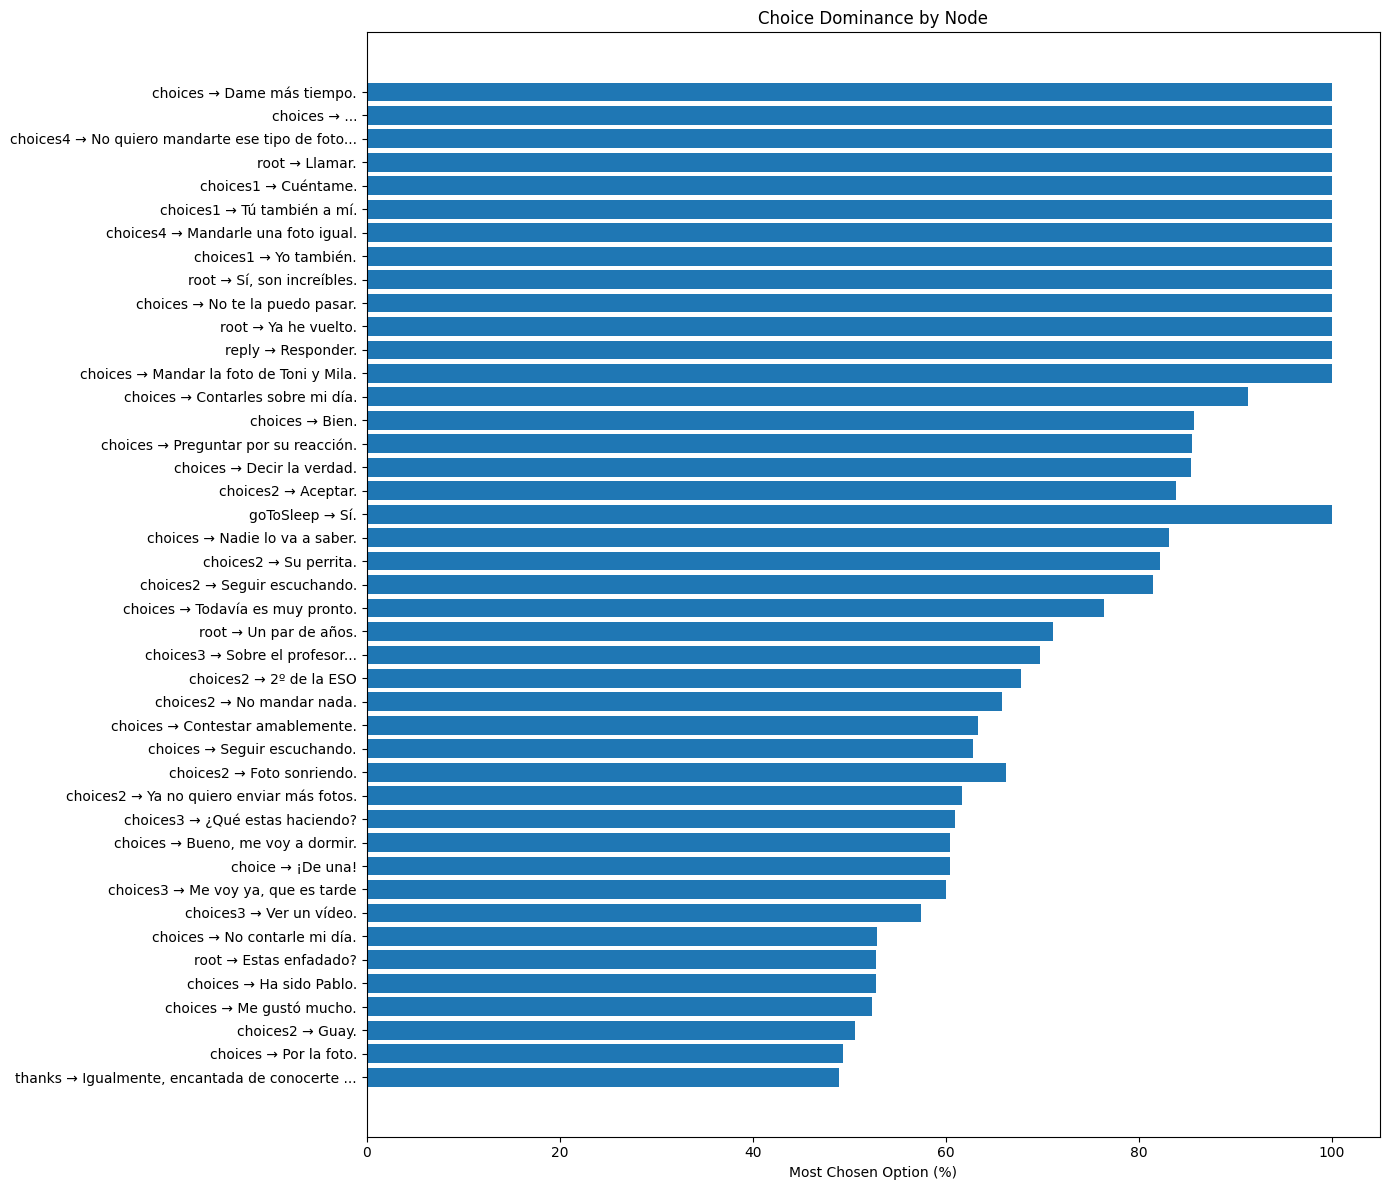

In [92]:
df_plot = df_most.sort_values("percentage")

labels = df_plot["short_node"] + " → " + df_plot["short_option"]

plt.figure(figsize=(14, 12))

plt.barh(labels, df_plot["percentage"])

plt.xlabel("Most Chosen Option (%)")
plt.title("Choice Dominance by Node")

plt.tight_layout()
plt.show()


In [93]:
target_nodes = {
	"Scene1Bedroom1.computer2.choices2": "school_year",
	"Scene1Lunch1.main.choices": "talk_parents_first_day_school",
	"Scene4Bedroom.phone.choices": "harassment_conflict_friend",
	"Scene4Garage.photo.choices": "suspicious_gift_photo",
	"Scene4Garage.interruption.choices": "stop_sending_gift_photo",
	"Scene5Livingroom.choices": "argument_with_harasser",
	"Scene6Bedroom.phone.choices2": "send_more_nudes",
	"Scene6BedroomRouteA1.phone.choices2": "agree_to_meet_harasser",
	"Scene6LunchRouteB.interruption.choices": "confess_to_parents"
}


In [94]:
node_response_counts = defaultdict(Counter)

for trace in traces:
	obj_id = trace.get("object", {}).get("id", "")

	if obj_id == CHOICE_OBJ_ID:
		extensions = trace.get("result", {}).get("extensions", {}) or {}

		node = extensions.get(NODE_EXT_ID)
		response = extensions.get(RESPONSE_EXT_ID)

		if node in target_nodes and response:
			node_response_counts[node][response] += 1
			
print(len(node_response_counts))
			

9


In [95]:
rows = []

for node, keywords in target_nodes.items():
	total = sum(node_response_counts[node].values())

	for option, count in node_response_counts[node].items():
		rows.append({
			"node": node,
			"keywords": keywords,
			"option": option,
			"count": count,
			"total": total,
		})

df_nodes = pd.DataFrame(rows)

df_nodes["percentage"] = df_nodes["count"] / df_nodes["total"]

# Columnas usadas para ordenar --> "node", "percentage"
# Orden de cada columna --> "node" (ascendente), "percentage" (descendente)
# inplace=True --> modifica df_nodes directamente
df_nodes.sort_values(["node", "percentage"], ascending=[True, False], inplace=True)

display(df_nodes)


,node,keywords,option,count,total,percentage
0,Scene1Bedroom1.computer2.choices2,school_year,2º de la ESO,61,90,0.677778
1,Scene1Bedroom1.computer2.choices2,school_year,4º de la ESO,16,90,0.177778
2,Scene1Bedroom1.computer2.choices2,school_year,3º de la ESO,8,90,0.088889
3,Scene1Bedroom1.computer2.choices2,school_year,1º de la ESO,5,90,0.055556
4,Scene1Lunch1.main.choices,talk_parents_first_day_school,Contarles sobre mi día.,84,92,0.913043
5,Scene1Lunch1.main.choices,talk_parents_first_day_school,No contarles sobre mi día.,8,92,0.086957
6,Scene4Bedroom.phone.choices,harassment_conflict_friend,Por la foto.,41,83,0.493976
7,Scene4Bedroom.phone.choices,harassment_conflict_friend,Prefiero no hablar de ello.,26,83,0.313253
8,Scene4Bedroom.phone.choices,harassment_conflict_friend,Por nuestra relación.,16,83,0.192771
11,Scene4Garage.interruption.choices,stop_sending_gift_photo,Nadie lo va a saber.,69,83,0.831325


In [96]:
fig = px.bar(
	df_nodes,
	x="percentage",
	y="keywords",
	color="keywords",
	orientation="h",
	hover_data={
		"option": True,
		"percentage": ":.2f",
		"keywords": False
	},
	title="Choice Distribution per Node"
)

fig.update_layout(
	yaxis_title="",
	xaxis_title="Percentage",
	height=900,
	showlegend=False
)

fig.update_xaxes(range=[0, 1])

fig.show()


In [97]:
target_nodes = {
	"Scene6Bedroom.phone.choices2": "send_more_nudes",
	"Scene6BedroomRouteA1.phone.choices2": "agree_to_meet_harasser",
	"Scene6LunchRouteB.interruption.choices": "confess_to_parents"
}


In [98]:
user_traces = defaultdict(list)

for trace in traces:
    user = trace.get("actor", {}).get("account", {}).get("name")
    if user:
        user_traces[user].append(trace)

END_NODES = {
    "END_MEET": "meet_harasser_in_person",
    "END_TELL": "confess_truth",
    "END_LIE": "hide_truth"
}

def classify_path(path: tuple):
    options = [opt for _, opt in path]

    if "Enviar otra foto." in options and "Aceptar." in options:
        return "END_MEET"
    
    if "Decir la verdad." in options:
        return "END_TELL"
    
    if "Mentir." in options:
        return "END_LIE"

def parse_time(timestamp: str | None):
	if not timestamp:
		return datetime.fromisoformat("1970-01-01T00:00:00+00:00")
	
	return datetime.fromisoformat(timestamp.replace("Z", "+00:00"))

def extract_sequence(traces: list):
    # Aunque las trazas ya están ordenadas por timestamp, se hace por precaución
    traces = sorted(
        traces,
        key=lambda trace: parse_time(trace.get("timestamp"))
    )

    seq = []
    for trace in traces:
        if trace.get("object", {}).get("id") == CHOICE_OBJ_ID:
            ext = trace.get("result", {}).get("extensions", {}) or {}

            node = ext.get(NODE_EXT_ID)
            option = ext.get(RESPONSE_EXT_ID)

            if node in target_nodes and option:
                seq.append((node, option))
                
    return seq

all_paths = []

for user, traces in user_traces.items():
    seq = extract_sequence(traces)
    all_paths.append(seq)
    
def clean_label(label):
    if label in target_nodes:
        return target_nodes[label]
    if label in END_NODES:
        return END_NODES[label]
    return label


In [99]:
flows = Counter()

for path in all_paths:
    for i in range(len(path)):
        node, option = path[i]

        flows[(node, option)] += 1
        
        if i < len(path) - 1:
            next_node, _ = path[i + 1]
            flows[(option, next_node)] += 1
        else:
            end_node = classify_path(path)
            flows[(option, end_node)] += 1

print("Total flow links:", len(flows))

outgoing_total = defaultdict(int)
for (src, dst), count in flows.items():
    outgoing_total[src] += count

labels = set()
for src, dst in flows:
    labels.add(src)
    labels.add(dst)

labels = list(labels)
label_to_idx = {label: i for i, label in enumerate(labels)}

sources = []
targets = []
values = []

for (src, dst), count in flows.items():
    total = outgoing_total[src]
    norm = count / total

    sources.append(label_to_idx[src])
    targets.append(label_to_idx[dst])
    values.append(norm)

display_labels = [clean_label(label) for label in labels]


Total flow links: 12


In [100]:
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",

    node=dict(
        pad=20,
        thickness=25,
        label=display_labels,
        line=dict(color="black", width=0.5),
    ),

    link=dict(
        source=sources,
        target=targets,
        value=values,
        hovertemplate="Flow: %{value:.2f}<extra></extra>"
    )
)])

fig.update_layout(
    title=dict(
        text="Decision Flow with Outcomes",
        x=0.5,
        xanchor="center"
    ),
    font_size=11,
    height=750,
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.show()


In [101]:
edges = defaultdict(int)

for path in all_paths:
    for i in range(len(path)):
        node, response = path[i]

        if i < len(path) - 1:
            next_node, _ = path[i + 1]
        else:
            next_node = classify_path(path)

        edges[(node, response, next_node)] += 1
        
outgoing_total = defaultdict(int)
for (src, response, dst), count in edges.items():
    outgoing_total[src] += count

# print(edges)


In [102]:
dot = Digraph("decision_tree", format="png")

dot.attr(
    rankdir="LR",
    splines="true",
    nodesep="0.6",
    ranksep="0.8"
)

dot.attr("node", shape="box", style="rounded,filled", color="lightblue2")


In [103]:
for (src, response, dst), count in edges.items():
    prob = count / outgoing_total[src]
    pct = prob * 100

    dot.edge(
        clean_label(src),
        clean_label(dst),
        label=f"{response} ({pct:.2f}%)",
        # Escalar de 1 a 6
        penwidth=str(1 + 5 * prob)
    )


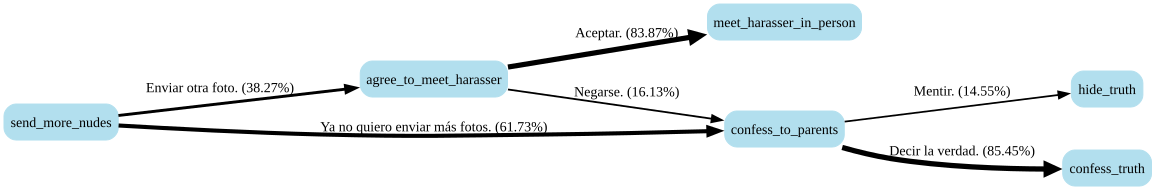

In [104]:
dot.render("decision_tree_graphviz", view=True)

display(dot)
    